# Sampel 2, Umum

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import skan
from utils import *

In [3]:
connected = cv2.imread("sampel-2_motif-total-sambung.png")
connected_binary = binarize(connected)
disconnected = cv2.imread("sampel-2_motif-total-pisah.png")
disconnected_binary = binarize(disconnected)

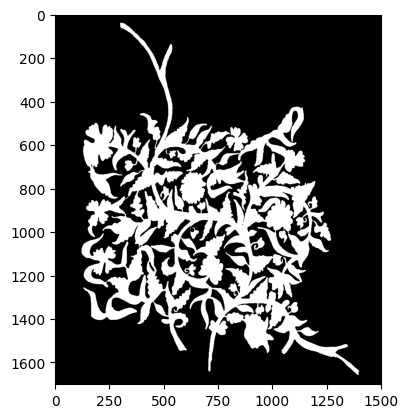

In [4]:
plt.imshow(connected_binary[700:2401, 0:1501], cmap='grey')

## Objek Tersambung

1

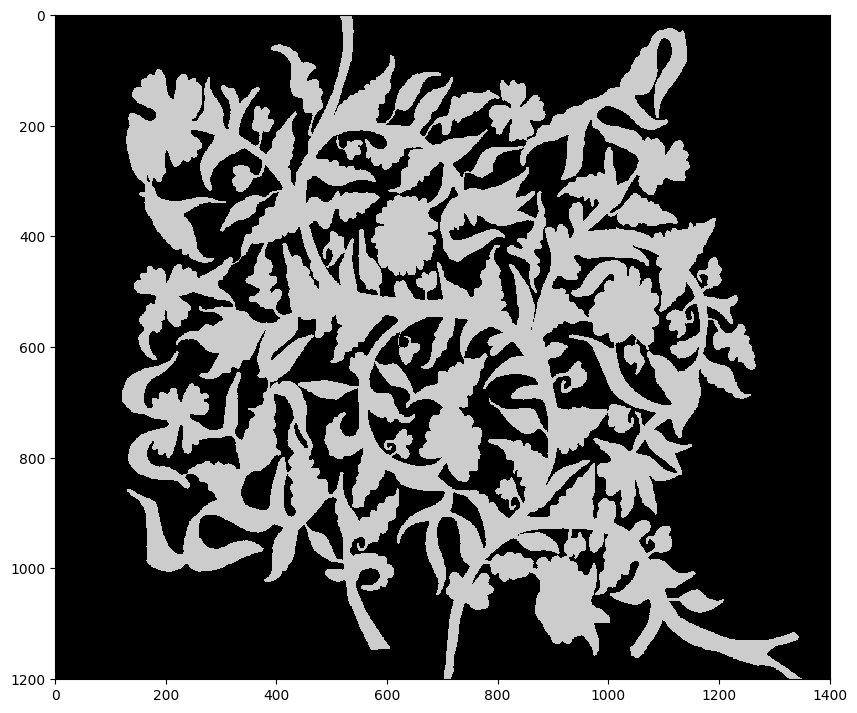

In [5]:
num_connected, connected_map = cv2.connectedComponents(connected_binary)

plt.figure(figsize=(10,10))
plt.imshow(connected_map[1100:2301, 0:1401], cmap='nipy_spectral', interpolation='nearest')

num_connected - 1

In [6]:
connected_cropped = connected_binary[1300:2100, 200:1000]

area_occupancy = getAreaOccupancy(connected_cropped)

print(f"Occupancy: {(area_occupancy*100):.2f}%")

Occupancy: 56.30%


## Dinamika Ruang Kosong

(800, 800)

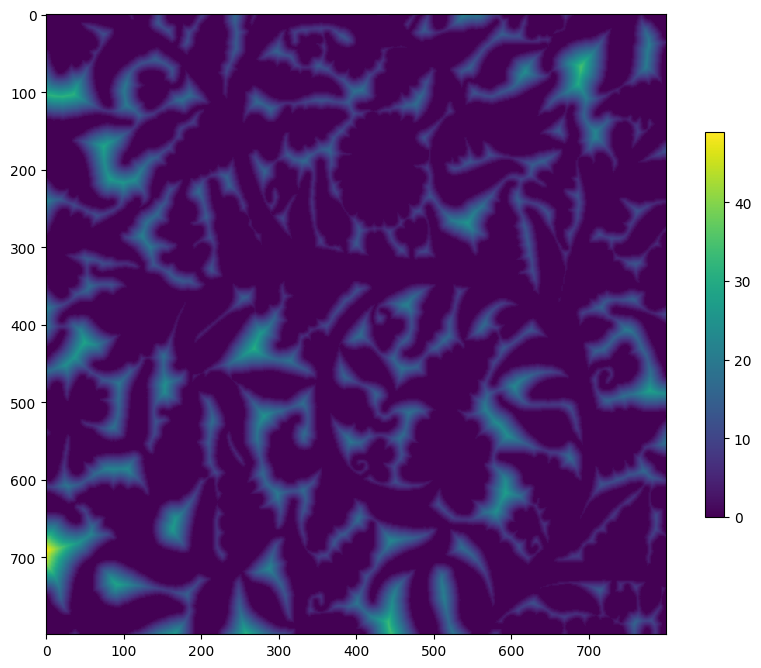

In [7]:
void_distance = cv2.distanceTransform(~connected_cropped, cv2.DIST_L2, 5)

plt.figure(figsize=(10,10))
plt.imshow(void_distance, interpolation='nearest')
plt.colorbar(shrink=0.5)

void_distance.shape

DATA SUMMARY of [Void Distance]:
Num     : 279675
Mean    : 7.5262
SD      : 5.8672
SD rel  : 77.96%
Median  : 6.0000
MAD     : 3.3907
MAD rel : 56.51%
Min     : 1.0000
Max     : 48.9783



{'num': 279675,
 'mean': 7.5262485,
 'sd': 5.8671713,
 'median': 6.0,
 'mad': 3.3906994,
 'min': 1.0,
 'max': 48.97829}

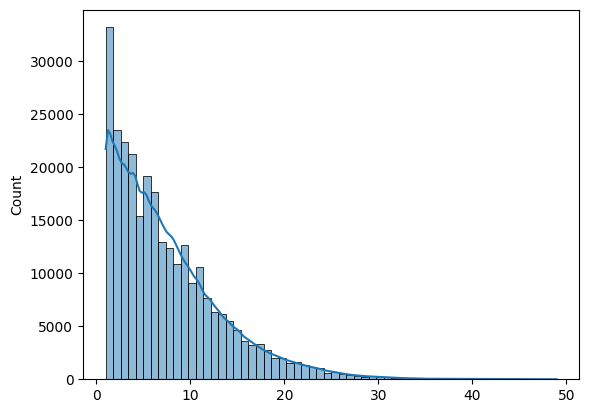

In [8]:
sns.histplot(void_distance[void_distance > 0], kde=True, bins=60)

summarizeData(void_distance[void_distance > 0], "Void Distance")

## Objek Terlepas

42

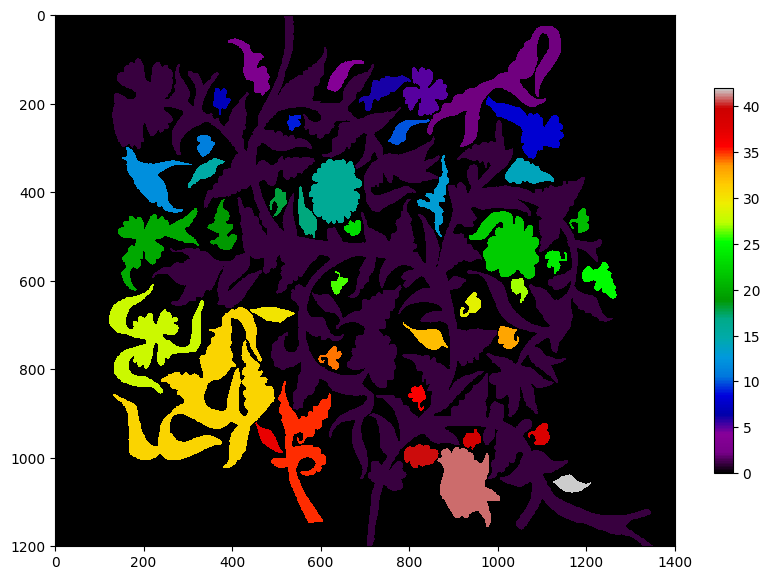

In [9]:
num_disconnected, disconnected_map = cv2.connectedComponents(disconnected_binary)

plt.figure(figsize=(10,10))
plt.imshow(disconnected_map[1100:2301, 0:1401], cmap='nipy_spectral', interpolation='nearest')
plt.colorbar(shrink=0.5)

num_disconnected - 1

## Daun yang Menempel

In [10]:
leaf = cv2.imread("sampel-2_motif-daun.png")
leaf_binary = binarize(leaf)

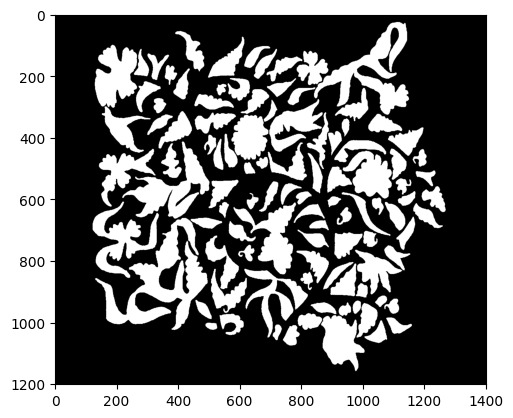

In [11]:
plt.imshow(leaf_binary[1100:2301, 0:1401], cmap='grey')

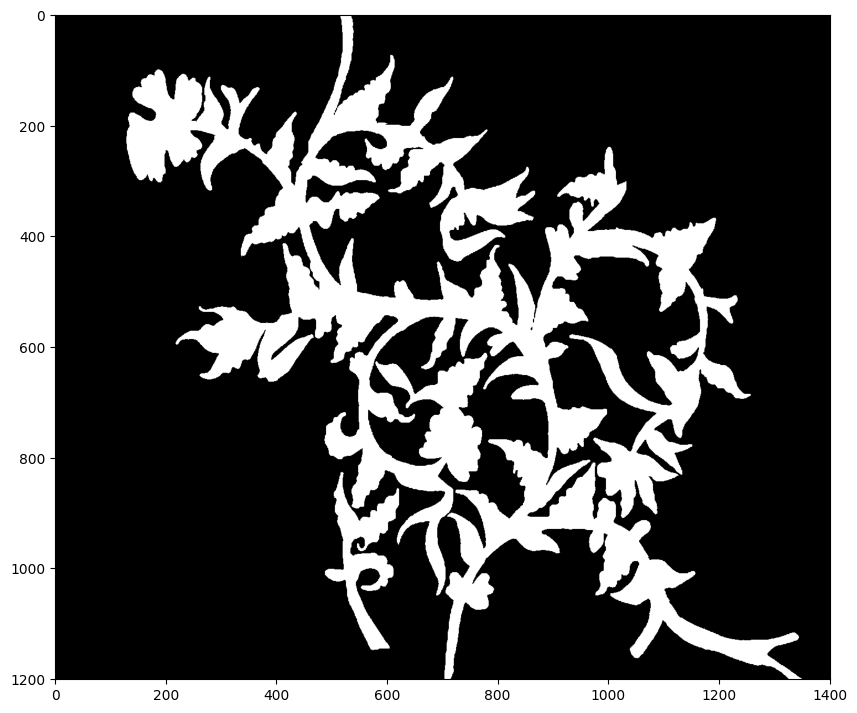

In [12]:
plt.figure(figsize=(10, 10))
plt.imshow(((disconnected_map == 1) | (disconnected_map == 35))[1100:2301, 0:1401], cmap='grey')

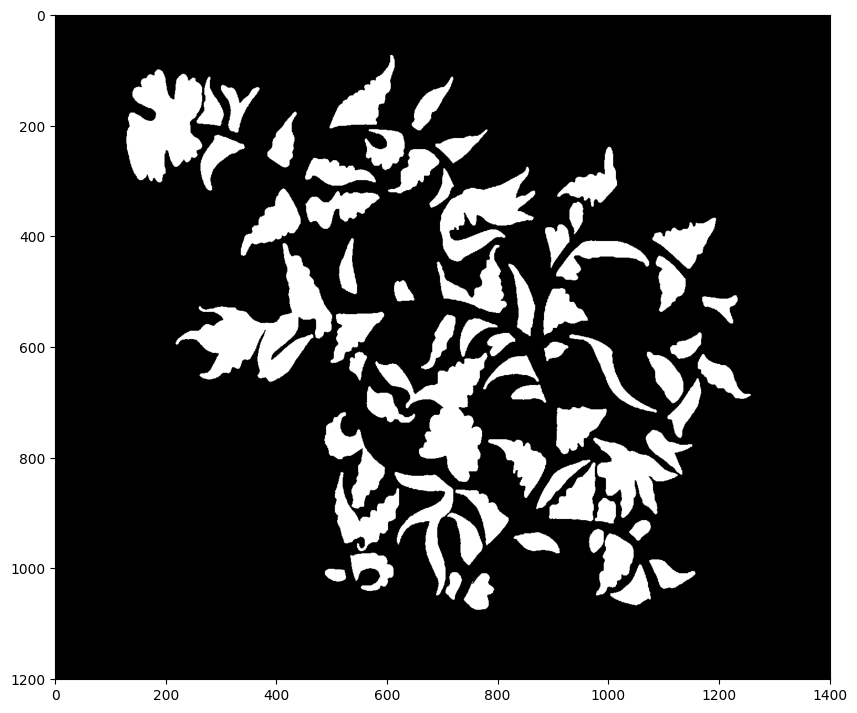

In [13]:
num_leaf, leaf_map = cv2.connectedComponents(leaf_binary)

leaf_to_branch = (leaf_binary & ((disconnected_map == 1) | (disconnected_map == 35))).astype(np.uint8) * 255

plt.figure(figsize=(10, 10))
plt.imshow(leaf_to_branch[1100:2301, 0:1401], cmap='grey')

In [14]:
leaf_to_branch_percent = np.count_nonzero(leaf_to_branch) / np.count_nonzero(leaf_binary)

print(f"Leaf to Branch: {leaf_to_branch_percent*100:.2f}%")

Leaf to Branch: 53.85%
